In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
medical_data =pd.read_csv("medical_raw_data.csv")
df=medical_data
df.shape

(10000, 53)

In [3]:
#First Step Cleaning Data

In [4]:
# Fill NA Categorical Columns
df['Anxiety'] = df['Anxiety'].replace({ 1 :'Yes' , 0:'No' })
df['Overweight'] = df['Overweight'].replace({ 1 :'Yes' , 0:'No' })

df['Anxiety'] = df['Anxiety'].fillna(df['Anxiety'].mode()[0])
df['Soft_drink'] = df['Soft_drink'].fillna(df['Soft_drink'].mode()[0])
df['Overweight'] = df['Overweight'].fillna(df['Overweight'].mode()[0])
df['HighBlood'] = df['HighBlood'].fillna(df['HighBlood'].mode())
df['Stroke'] = df['Stroke'].fillna(df['Stroke'].mode())
df['Arthritis'] = df['Arthritis'].fillna(df['Arthritis'].mode())
df['Diabetes'] = df['Diabetes'].fillna(df['Diabetes'].mode())
df['Hyperlipidemia'] = df['Hyperlipidemia'].fillna(df['Hyperlipidemia'].mode())
df['Diabetes'] = df['Diabetes'].fillna(df['Diabetes'].mode())
df['Allergic_rhinitis'] = df['Allergic_rhinitis'].fillna(df['Allergic_rhinitis'].mode())
df['Reflux_esophagitis'] = df['Reflux_esophagitis'].fillna(df['Reflux_esophagitis'].mode())
df['Asthma'] = df['Asthma'].fillna(df['Asthma'].mode())
df['Income'] = df['Income'].fillna(df['Income'].median()) 
df['Children'] =df['Children'].fillna(df['Children'].median())
df['Age'] = df['Age'].fillna(df['Age'].median())
df['VitD_supp']=df['VitD_supp'].fillna(df['VitD_supp'].median())
df['Lat'] = df['Lat'].fillna(df['Lat'].median())
df['Lng'] = df['Lng'].fillna(df['Lng'].median())
df['Population'] = df['Population'].fillna(df['Population'].median())
df['VitD_levels'] = df['VitD_levels'].fillna(df['VitD_levels'].median())
df['Doc_visits'] = df['Doc_visits'].fillna(df['Doc_visits'].median())
df['Full_meals_eaten'] = df['Full_meals_eaten'].fillna(df['Full_meals_eaten'].median())
df['Initial_days'] = df['Initial_days'].fillna(df['Initial_days'].median())
df['TotalCharge']= df['TotalCharge'].fillna(df['TotalCharge'].median())
df['Additional_charges']= df['Additional_charges'].fillna(df['Additional_charges'].median())

bool_series = pd.isnull(df)
missing_values_count = bool_series.sum()
filtered_data = df[bool_series]
print(missing_values_count)

Unnamed: 0            0
CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
Timezone              0
Job                   0
Children              0
Age                   0
Education             0
Employment            0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
VitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services        

In [5]:
df["Item1"].astype("category")
df["Item2"].astype("category")
df["Item3"].astype("category")
df["Item4"].astype("category")
df["Item5"].astype("category")
df["Item6"].astype("category")
df["Item7"].astype("category")
df["Item8"].astype("category")

#Rename a few columns, unamed, item1-8
df.rename({"Unnamed: 0":"A"}, axis="columns", inplace=True)
df.rename({"Item1":"Timely_admission"}, axis="columns", inplace=True)
df.rename({"Item2":"Timely_treatment"}, axis="columns", inplace=True)
df.rename({"Item3":"Timely_visits"}, axis="columns", inplace=True)
df.rename({"Item4":"Reliability"}, axis="columns", inplace=True)
df.rename({"Item5":"Options"}, axis="columns", inplace=True)
df.rename({"Item6":"Hours_of_treatment"}, axis="columns", inplace=True)
df.rename({"Item7":"Courteous_staff"}, axis="columns", inplace=True)
df.rename({"Item8":"Active_Listening_Doctor"}, axis="columns", inplace=True)
df.rename({"TotalCharge":"DailyCharge"}, axis="columns", inplace=True)
df.rename({"Lat":"Latitude"}, axis="columns", inplace=True)
df.rename({"Lng":"Longitude"}, axis="columns", inplace=True)

In [6]:
def rep_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)
        
        # Replacing outliers with the median
        df[col] = df[col].apply(lambda x: df[col].median() if x < lower_bound or x > upper_bound else x)

In [7]:
#Replace outliers for each column
rep_outliers(df, ['Latitude']) 
rep_outliers(df, ['VitD_supp'])
rep_outliers(df, ['Longitude'])  
rep_outliers(df, ['Population']) 
rep_outliers(df, ['VitD_supp'])
rep_outliers(df, ['Children'])  
rep_outliers(df, ['VitD_levels']) 
rep_outliers(df, ['Doc_visits'])
rep_outliers(df, ['Full_meals_eaten'])
rep_outliers(df, ['Initial_days'])  
rep_outliers(df, ['DailyCharge']) 
rep_outliers(df, ['Additional_charges'])

In [8]:
#change datatypes
df = df.astype({'Anxiety': 'category','Overweight': 'category','Children': 'category','VitD_supp': 'category','UID': 'str','Interaction': 'str','Zip': 'str','Children': 'Int64','UID': 'str','Interaction': 'str','Anxiety': 'str','Overweight': 'str','HighBlood': 'str','Stroke': 'str','Arthritis': 'str','Diabetes': 'str','Hyperlipidemia': 'str','Diabetes': 'str','Allergic_rhinitis': 'str','Reflux_esophagitis': 'str','Asthma': 'str','Latitude': 'int64','Longitude': 'int64','VitD_levels': 'int64','VitD_supp': 'int64','DailyCharge': 'int64','Additional_charges': 'int64','Initial_days': 'int64','DailyCharge': 'int64','CaseOrder' : 'int64','Customer_id' : 'object','Population' : 'int64','Area' : 'object','Timezone' : 'object','Job' : 'object','Age' : 'float64','Education' : 'object','Employment' : 'object','Marital' : 'object','Gender' : 'object','ReAdmis' : 'object','Doc_visits' : 'int64','Full_meals_eaten' : 'int64','Soft_drink' : 'object','Initial_admin' : 'object','Complication_risk' : 'object','Services' : 'object'})

In [9]:
#Rename a few columns
df.rename({"CaseOrder":"Patient_Num"}, axis="columns", inplace=True)
df.rename({"A":"CaseOrder"}, axis="columns", inplace=True)

# round daily charge, additonal_charge to no decimal points
df["Additional_charges"] = df.Additional_charges.round(0)
df["DailyCharge"] = df.DailyCharge.round(0)

#changing datatypes
df["Anxiety"].astype("category")
df["Overweight"].astype("category")
df["Children"].astype("category")
df["VitD_supp"].astype("category")
df["UID"].astype("str")
df["Interaction"].astype("str")
df["Zip"].astype("str")
df["Children"].astype("Int64")
#UID & Interaction to numerical
df["UID"].astype("str")
df["Interaction"].astype("str")
df["Zip"].astype("str")
df['Anxiety'].astype("str")
df['Overweight'].astype("str")
df['HighBlood'].astype("str")
df['Stroke'].astype("str")
df['Arthritis'].astype("str")
df['Diabetes'].astype("str")
df['Hyperlipidemia'].astype("str")
df['Diabetes'].astype("str")
df['Allergic_rhinitis'].astype("str")
df['Reflux_esophagitis'].astype("str")
df['Asthma'].astype("str")
df["Latitude"].astype("int64")
df["Longitude"].astype("int64")
df["VitD_levels"].astype("int64")
df["VitD_supp"].astype("int64")
df["DailyCharge"].astype("int64")
df["Additional_charges"].astype("int64")
df['Income'].astype("int64")
df['Initial_days'].astype("int64")
df['DailyCharge'] = df['DailyCharge'].astype("int64") 

In [10]:
df.shape

(10000, 53)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CaseOrder                10000 non-null  int64  
 1   Patient_Num              10000 non-null  int64  
 2   Customer_id              10000 non-null  object 
 3   Interaction              10000 non-null  object 
 4   UID                      10000 non-null  object 
 5   City                     10000 non-null  object 
 6   State                    10000 non-null  object 
 7   County                   10000 non-null  object 
 8   Zip                      10000 non-null  object 
 9   Latitude                 10000 non-null  int64  
 10  Longitude                10000 non-null  int64  
 11  Population               10000 non-null  int64  
 12  Area                     10000 non-null  object 
 13  Timezone                 10000 non-null  object 
 14  Job                    

In [12]:
#Data Analysis-Chi-square

In [13]:
#Chi square test
import scipy.stats as st
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df.Timely_admission, df.Timely_treatment)
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(contingency_table)

Timely_treatment    1    2     3     4    5    6  7
Timely_admission                                   
1                  65  113    31     4    0    0  0
2                 120  551   552    88    4    0  0
3                  25  571  1658  1024  126    0  0
4                   3  119  1069  1635  602   27  0
5                   0    6   128   560  579  101  3
6                   0    0     1    40  106   72  6
7                   0    0     0     0    4    3  3
8                   0    0     0     0    0    1  0


In [14]:
chi_analysis = st.chi2_contingency(contingency_table)
print(chi_analysis)

Chi2ContingencyResult(statistic=7637.372537949044, pvalue=0.0, dof=42, expected_freq=array([[4.5369000e+00, 2.8968000e+01, 7.3250700e+01, 7.1376300e+01,
        3.0267300e+01, 4.3452000e+00, 2.5560000e-01],
       [2.8009500e+01, 1.7884000e+02, 4.5222850e+02, 4.4065650e+02,
        1.8686150e+02, 2.6826000e+01, 1.5780000e+00],
       [7.2505200e+01, 4.6294400e+02, 1.1706356e+03, 1.1406804e+03,
        4.8370840e+02, 6.9441600e+01, 4.0848000e+00],
       [7.3591500e+01, 4.6988000e+02, 1.1881745e+03, 1.1577705e+03,
        4.9095550e+02, 7.0482000e+01, 4.1460000e+00],
       [2.9330100e+01, 1.8727200e+02, 4.7355030e+02, 4.6143270e+02,
        1.9567170e+02, 2.8090800e+01, 1.6524000e+00],
       [4.7925000e+00, 3.0600000e+01, 7.7377500e+01, 7.5397500e+01,
        3.1972500e+01, 4.5900000e+00, 2.7000000e-01],
       [2.1300000e-01, 1.3600000e+00, 3.4390000e+00, 3.3510000e+00,
        1.4210000e+00, 2.0400000e-01, 1.2000000e-02],
       [2.1300000e-02, 1.3600000e-01, 3.4390000e-01, 3.351000

In [15]:
alpha = 0.05
if p < alpha:
    print("There is a signifcant association between the variables.")
else:
    print("There is no signifcant association between the variables.")

There is a signifcant association between the variables.


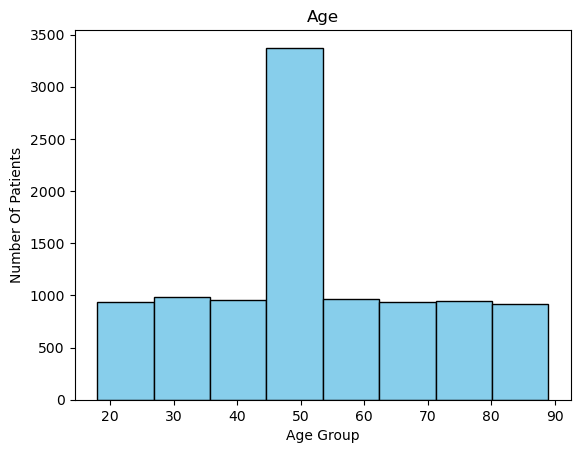

<Axes: title={'center': 'Income'}, xlabel='Income', ylabel='Patients Number'>

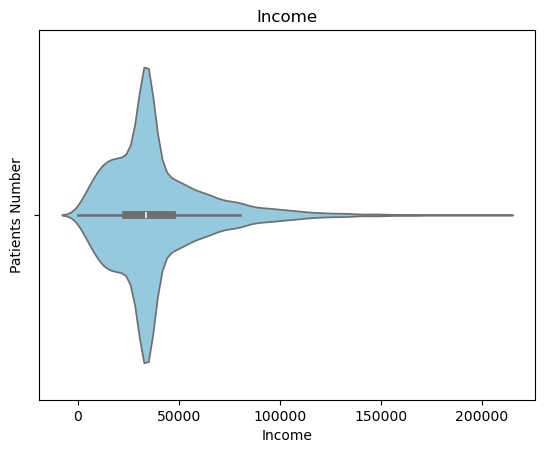

In [16]:
#Identify the distribution of two continuous variables  Histogram and violin plot
data = df.Age
plt.xlabel('Age Group')
plt.ylabel('Number Of Patients')
plt.title('Age')
plt.hist(data, bins = 8, color='skyblue', edgecolor='black')
plt.show()

plt.xlabel("Income")
plt.ylabel("Patients Number")
plt.title("Income")
sns.violinplot(data=df, x="Income", color="skyblue", inner="box")

In [17]:
#describe for age & income
df.Age.describe()

count    10000.00000
mean        53.22430
std         17.99382
min         18.00000
25%         41.00000
50%         53.00000
75%         65.00000
max         89.00000
Name: Age, dtype: float64

In [18]:
df.Income.describe()

count     10000.000000
mean      38872.450471
std       25042.796229
min         154.080000
25%       23956.162500
50%       33942.280000
75%       46466.797500
max      207249.130000
Name: Income, dtype: float64

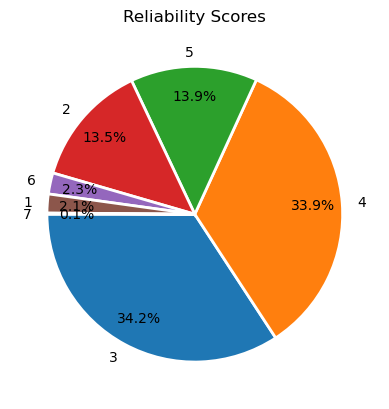

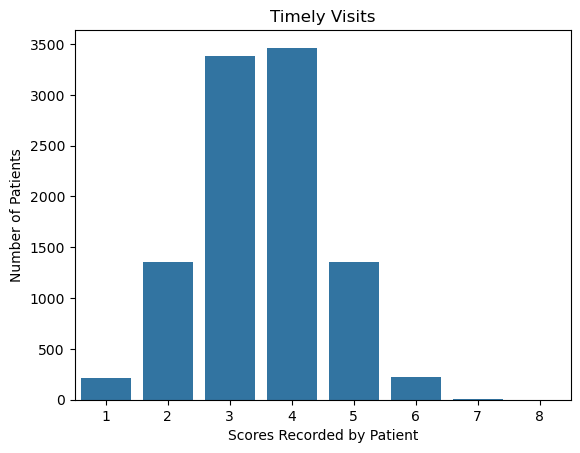

In [19]:
#two categorical variables using univariate statistics Pie chart 
plt.xlabel('')
plt.ylabel('')
plt.title('Reliability Scores')
Labels= [1,2,3,4,5,6,7,8]
y = df["Reliability"].value_counts()
wp = {'linewidth': 2.0, 'edgecolor':'white'}
plt.pie(y, labels=y.index,startangle=180, labeldistance= 1.1, pctdistance=0.8, autopct='%1.1f%%', wedgeprops=wp )
plt.show()

TimelyV = df.Timely_visits
sns.countplot(x=TimelyV)
plt.title("Timely Visits")
plt.ylabel('Number of Patients')
plt.xlabel('Scores Recorded by Patient')
plt.show()

In [20]:
#describe for reliability & timely admission
df.Reliability.value_counts()

Reliability
3    3422
4    3394
5    1388
2    1346
6     231
1     207
7      12
Name: count, dtype: int64

In [21]:
df.Timely_admission.value_counts()

Timely_admission
4    3455
3    3404
5    1377
2    1315
6     225
1     213
7      10
8       1
Name: count, dtype: int64

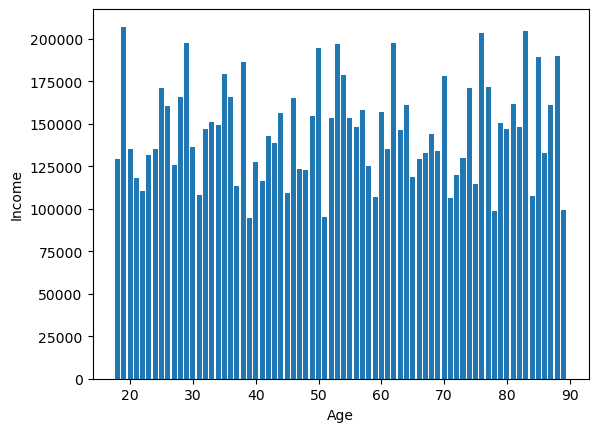

In [22]:
#Identify the distribution of two continuous variables Crosschart/stacked bar chart
Age = df.Age
Income = df.Income
plt.bar(Age,Income)
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

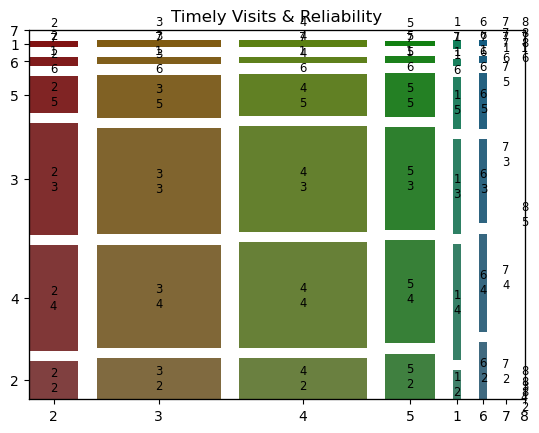

In [23]:
#two categorical variables Mosaic plot
from statsmodels.graphics.mosaicplot import mosaic
mosaic(df, ['Timely_visits', 'Reliability'],  gap=0.05, title='Timely Visits & Reliability')
plt.show()

In [24]:
pip install pytest